# Hugging Face `pipeline`으로 NLP 모델 시연하기

Hugging Face는 사전학습 모델, 데이터셋과 자연어 처리 도구를 공유하고 사용할 수 있게 제공하는 AI 생태계이다. Transformers 라이브러리의 **`pipeline()`** 은 사전학습 모델을 이용한 추론 과정을 하나의 호출로 묶어 주는 고수준 API이다.

일반적으로 모델을 사용하려면 `문자열 토큰화 → 토큰 ID와 mask 생성 → 모델 forward → 출력 후처리` 단계를 직접 연결해야 한다. `pipeline()`은 선택한 NLP 작업에 맞춰 토크나이저, 모델과 후처리를 자동으로 연결하고 `label`, `score`, 완성 문장처럼 사람이 읽기 쉬운 결과를 반환한다.

```text
입력 문자열 → 토크나이저 → 토큰 ID와 mask → 사전학습 모델 → 작업별 결과
```

`pipeline()`은 이미 학습된 가중치로 결과를 계산하는 **추론(Inference)** 도구이다. 호출만으로 모델이 새 데이터를 학습하거나 가중치를 수정하지 않는다. 편리함의 핵심은 코드를 짧게 만드는 데 있지만, `task` 이름과 모델 head가 맞지 않으면 실행되지 않거나 의미 없는 결과가 나온다. 따라서 **task–model–입력–출력 계약**을 먼저 확인해야 한다.

이 노트북은 이미 다른 BERT 실습에서 사용하는 `klue/bert-base` 체크포인트 하나를 재사용해 fill-mask를 대표 시연한다. 여러 대형 모델을 연속으로 다운로드하는 나열형 실습은 제외한다.


## 1. task–model 계약

task(* 개발에서는 보통 '할일, 순서'를 의미)는 원하는 결과 형식을 정하고, model checkpoint는 그 task에 맞는 head와 학습 이력을 제공해야 한다. `fill-mask`는 Masked Language Modeling head, `text-classification`은 분류 head, `token-classification`은 토큰별 분류 head가 필요하다. 같은 BERT 계열이어도 head와 fine-tuning 목적이 다르면 서로 바꿔 쓸 수 없다.

모델 카드에서 언어, 학습 목적, label 의미, 입력 길이를 확인해야 한다. 여기서는 한국어 WordPiece와 MLM 사전학습을 제공하는 `klue/bert-base`를 명시한다. `pipeline("fill-mask")`처럼 모델을 생략하면 라이브러리 버전에 따라 기본 체크포인트가 바뀔 수 있다.


In [1]:
# pipeline은 task에 맞는 토크나이저, 모델과 결과 후처리를 연결한다.
from transformers import pipeline

# task는 수행할 작업이고 MODEL_ID는 사용할 사전학습 checkpoint이다.
TASK = "fill-mask"
MODEL_ID = "klue/bert-base"

# 이 사전은 fill-mask가 요구하는 모델 head, 입력과 반환 key를 정리한다.
task_contract = {
    "task": TASK,
    "required_head": "Masked Language Modeling head",
    "input": "정확히 하나의 [MASK]를 포함한 한국어 문장",
    "output": "token_str, score, sequence를 가진 후보 목록",
}

# items()로 계약 사전의 key와 설명을 한 줄씩 출력한다.
for key, value in task_contract.items():
    print(f"{key:14s}: {value}")


task          : fill-mask
required_head : Masked Language Modeling head
input         : 정확히 하나의 [MASK]를 포함한 한국어 문장
output        : token_str, score, sequence를 가진 후보 목록


## 2. 모델과 토크나이저를 명시해 pipeline 만들기

pipeline을 만들 때 model과 tokenizer를 같은 체크포인트로 명시하면 입력 ID와 모델 어휘가 일치한다. CPU를 명시하려면 `device=-1`을 사용하고, GPU에서는 사용할 장치 번호를 넣는다.

반환값은 점수가 높은 순서의 dict 목록이다. `token_str`은 `[MASK]`에 들어갈 후보 토큰, `score`는 해당 위치에서의 softmax 점수, `sequence`는 후보를 넣어 복원한 문장이다. 이 점수는 후보 간 상대값이며 사실성이나 문장 전체 품질을 보증하지 않는다.


In [2]:
# 같은 checkpoint의 모델과 토크나이저를 연결해 토큰 ID와 어휘를 일치시킨다.
# pooler·seq_relationship UNEXPECTED는 MLM에 필요 없는 NSP 계층을 제외했다는 정상 안내이다.
mask_filler = pipeline(
    task=TASK,  # fill_mask
    model=MODEL_ID, # KLUE
    tokenizer=MODEL_ID, # KLUE
    # -1은 CPU에서 추론한다는 설정이다.
    device=-1,
)

# mask_token은 현재 토크나이저가 사용하는 특수 토큰 [MASK]를 반환한다.
masked_text = f"대한민국의 수도는 {mask_filler.tokenizer.mask_token}이다."
# top_k=5는 [MASK]에 들어갈 점수가 높은 후보 다섯 개를 반환한다.
results = mask_filler(masked_text, top_k=5)

print("input:", masked_text)
# result 하나에는 후보 토큰, 상대 점수와 후보를 넣은 전체 문장이 저장된다.
for rank, result in enumerate(results, start=1):
    print(
        f"{rank}: token={result['token_str']!r}, "
        f"score={result['score']:.4f}, "
        f"sequence={result['sequence']}"
    )


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


input: 대한민국의 수도는 [MASK]이다.
1: token='서울', score=0.5955, sequence=대한민국의 수도는 서울 이다.
2: token='광화문', score=0.0811, sequence=대한민국의 수도는 광화문 이다.
3: token='평양', score=0.0472, sequence=대한민국의 수도는 평양 이다.
4: token='부산', score=0.0294, sequence=대한민국의 수도는 부산 이다.
5: token='인천', score=0.0265, sequence=대한민국의 수도는 인천 이다.


## 3. pipeline을 쓸 때와 직접 호출할 때

pipeline은 빠른 시연, 모델 후보 점검, 간단한 서비스 프로토타입에 적합하다. 반면 배치별 tensor shape, loss, attention mask, threshold, 사용자 정의 후처리를 통제해야 하면 `AutoTokenizer`와 task 전용 `AutoModel...` 클래스를 직접 호출하는 편이 낫다.

여러 task를 보여 주기 위해 서로 다른 대형 모델을 한 노트북에서 순차 로딩하면 다운로드 시간과 메모리가 핵심 개념을 가린다. 먼저 한 task의 계약과 결과 구조를 완전히 이해한 뒤 필요할 때 다른 task로 확장한다.


## pipeline 전체 흐름 정리

task를 먼저 정하고 언어와 head가 맞는 checkpoint를 명시한다. 입력을 전달한 뒤 반환된 key와 점수의 의미를 task 계약에 맞춰 해석한다.

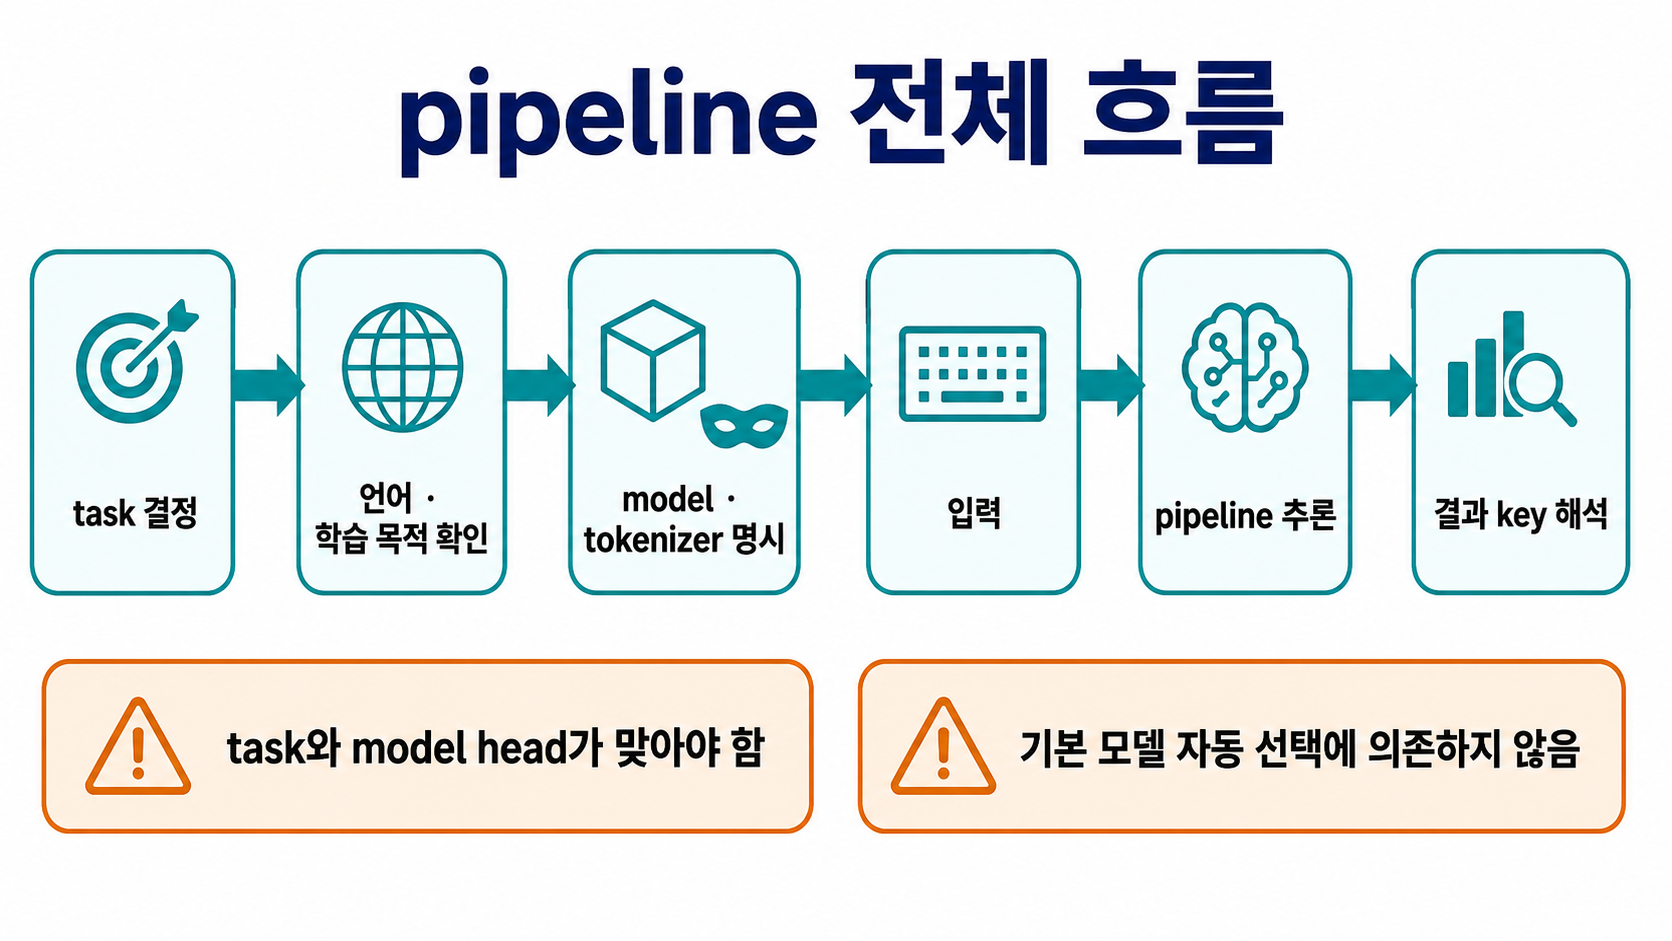
